# Chapter 3. Classification

In [79]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve

## 1. MNIST

In [3]:
mnist = fetch_openml('mnist_784', as_frame=True)
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [4]:
X, y = mnist['data'], mnist['target']
print(X)
print(y)

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ...  pixel7

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

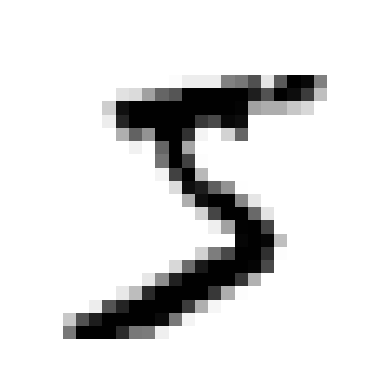

In [5]:
plt.imshow(X.iloc[0].to_numpy().reshape(28, 28), cmap = 'binary')
plt.axis('off')

In [6]:
y[0]

'5'

In [8]:
# The MNIST dataset is already split into a training set (the first 60,000 images) and a test set (the last 10,000 images). So we can just split it like this:
X_train = X.iloc[:60000]
X_test  = X.iloc[60000:]
y_train = y.iloc[:60000]
y_test  = y.iloc[60000:]

## 2. Training a Binary Classifier

Goal: distinguish two classes, 5 and non-5.

In [9]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [ ]:
sgd_clf = SGDClassifier(random_state=316)

sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict(X_train.iloc[:5])

array([ True, False, False, False, False])

## 3. Performance Measures

### 3.1. Measuring Accuracy Using Cross-Validation

In [ ]:
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 316)

In [ ]:
cross_val_score(sgd_clf, X_train, y_train_5, cv = kf, scoring = 'accuracy')

array([0.94891667, 0.95775   , 0.96675   , 0.96475   , 0.96375   ])

In [25]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
cross_val_score(dummy_clf, X_train, y_train_5, cv = kf, scoring = 'accuracy')

array([0.90958333, 0.90966667, 0.90966667, 0.90966667, 0.90966667])

Above results demonstrate why accuracy is generally not the preferred performance measure for classifiers, especially when dealing with skewed datasets. **Confusion matrix (CM)** is a better approach to evaluate the performance of a classifier.

### 3.2. Confusion Matrices

This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).

In [31]:
y_train_5_cv_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = kf)

In [32]:
cm = confusion_matrix(y_train_5, y_train_5_cv_pred)
cm

array([[54051,   528],
       [ 1849,  3572]])

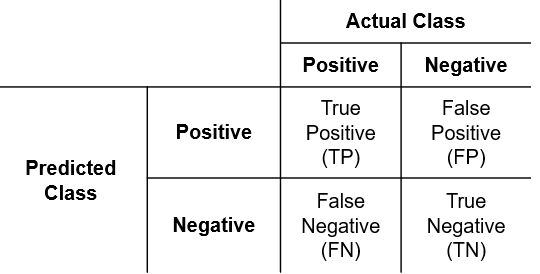
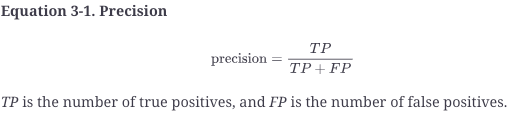
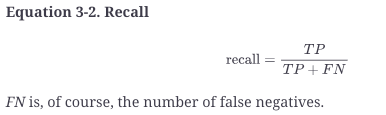
<br>

- ***Precision***: Among the samples I predicted as positive, how many are actually true? 
    - Aim of the metric: Reduce false positives, avoid mistaken classification
- ***Recall***: Among all the true positive samples, how many did I capture?
    - Aim of the metric: don't miss any positive instances.

### 3.3. Precision and Recall

It is often convenient to combine precision and recall into a single metric called the ***F1 score***, especially when you need a single metric to compare two classifiers. The F1 score is the **harmonic mean** of precision and recall (Equation 3-3). Whereas the regular mean treats all values equally, the harmonic mean gives much more weight to low values.
<br>

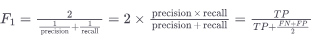
<br>
**The F1 score favors classifiers that have similar precision and recall**. This is not always what you want: in some contexts you mostly care about precision, and in other contexts you really care about recall.

In [43]:
print(f'The Precision is {precision_score(y_train_5, y_train_5_cv_pred)}')
print(f'The Recall is {recall_score(y_train_5, y_train_5_cv_pred)}')
print(f'The F1 score is {f1_score(y_train_5, y_train_5_cv_pred)}')

The Precision is 0.871219512195122
The Recall is 0.6589190186312488
The F1 score is 0.7503413506984561


### 3.4. The Precision/Recall Trade-Off

**The precision/recall trade-off**: Increasing precision reduces recall, and vice versa.
<br>
To understand this trade-off, let’s look at how the `SGDClassifier` makes its classification decisions. For each instance, it computes a score based on a decision function. If that score is greater than a threshold, it assigns the instance to the positive class; otherwise it assigns it to the negative class. 

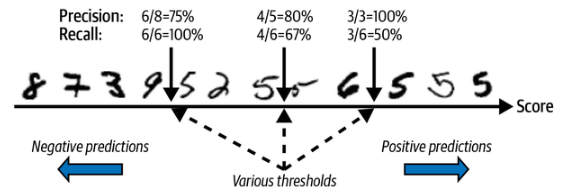

The `SGDClassifier` users a threshold equal to 0. 

In [59]:
y_score = sgd_clf.decision_function(X_train.iloc[[0]])
print(y_score)

[4342.30802343]


In [62]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = kf, 
                             method = 'decision_function')

In [73]:
precision, recall, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precision.shape)
print(recall.shape)
print(thresholds.shape)

(60001,)
(60001,)
(60000,)


The last precision and recall values are 1 and 0, respectively, and do not have a corresponding threshold. This ensures that the graph starts on the y axis. 

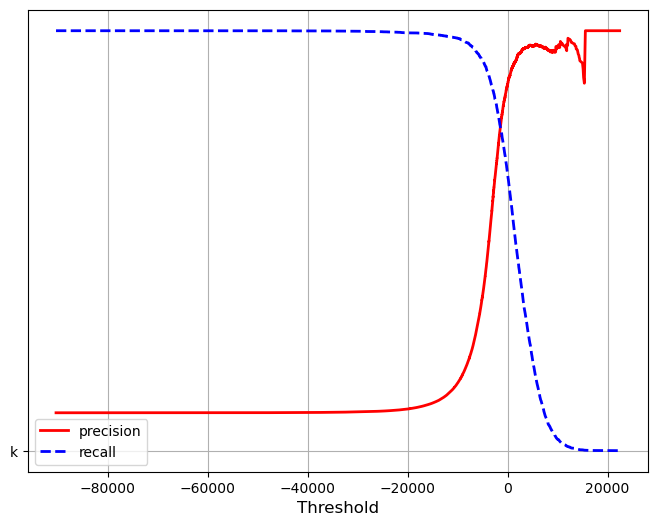

In [75]:
fig, ax = plt.subplots(figsize = (8,6))
ax.plot(thresholds, precision[:-1], 'r-', linewidth = 2, label = 'precision')
ax.plot(thresholds, recall[:-1], 'b--', linewidth = 2, label = 'recall')
ax.vlines(thresholds, 0, "k", linewidth = 4)
ax.set_xlabel('Threshold', fontsize = 12)
ax.legend()
ax.grid(True)
plt.show()

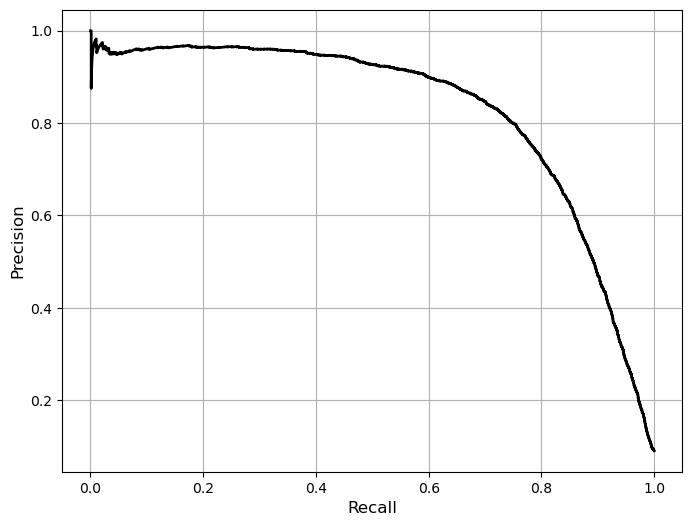

In [77]:
fig, ax = plt.subplots(figsize = (8,6))
ax.plot(recall[:-1], precision[:-1], 'k-', linewidth = 2)
ax.set_xlabel('Recall', fontsize = 12)
ax.set_ylabel('Precision', fontsize = 12)
ax.grid(True)
plt.show()

We can customized our threshoulds.

In [78]:
y_train_5_cv_pred_3000 = y_scores > 3000
print(f'Precision score is {precision_score(y_train_5, y_train_5_cv_pred_3000)}')
print(f'Recall score is {recall_score(y_train_5, y_train_5_cv_pred_3000)}')
print(f'F1 score is {f1_score(y_train_5, y_train_5_cv_pred_3000)}')

Precision score is 0.9553868058851448
Recall score is 0.37133370226895407
F1 score is 0.5348034006376196


### 3.5. The ROC Curve

The ROC curve plots the **recall** again (**1 - specificity**)

In [86]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [87]:
print(fpr.shape)
print(tpr.shape)
print(thresholds.shape)

(3730,)
(3730,)
(3730,)


As a rule of thumb, we prefer the precision/recall (PR) curve whenever the positive class is rare or when you care more about the false positives than the false negatives. Otherwise, use the ROC curve.

## 4. Multiclass Classification

## 5. Error Analysis

## 6. Multilabel Classification

## 7. Multioutput Classification